# Tutorial 4: Spectrum smoothing and weighting

Measured spectra are noisy. Transfer functions estimated from a single sweep or
from a noise excitation show a lot of details that are not relevant, especially
at high frequencies where the frequency resolution of the FFT is much finer than
what the ear, or the physics of the problem, actually distinguishes.

This tutorial presents the two related tools that measpy provides:

- **smoothing**, which averages a spectrum over frequency bands whose width is
  proportional to the frequency (1/nth octave bands),
- **weighting** (```measpy.Weighting``` objects), which describes a gain and a
  phase as a function of frequency, given on a small number of frequencies.
  Weightings are used for dBA/dBC curves, for microphone response corrections,
  and as a compact representation of a smoothed spectrum.

In [1]:
#This is here in case we want to use the local measpy directory
import sys
sys.path.insert(0, "..")

import measpy as mp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

## 1. A noisy transfer function

To have something to smooth, let us build a synthetic system with two
resonances, measure it with a white noise, and estimate its transfer function
with Welch's method. The result is the kind of noisy spectrum that a real
measurement produces.

array([<Axes: xlabel='Freq (Hz)', ylabel='20 Log $|$H$|$ (-)'>,
       <Axes: xlabel='Freq (Hz)', ylabel='Phase (rad)'>], dtype=object)

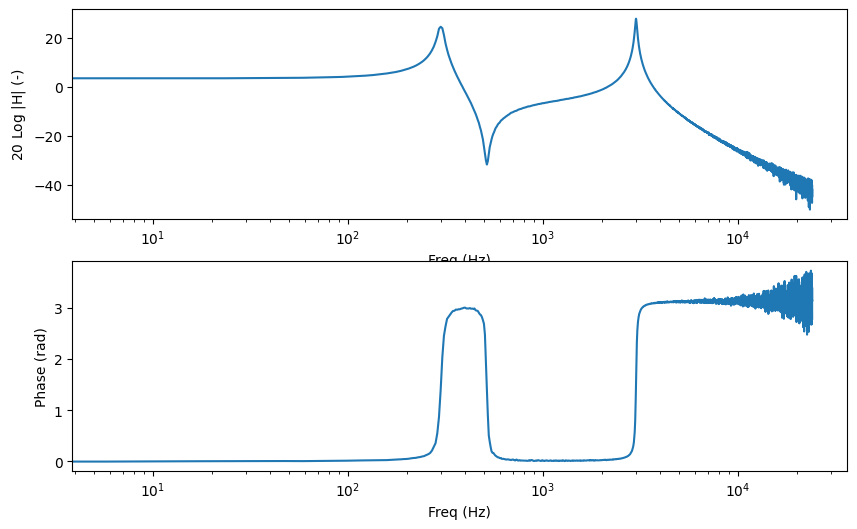

In [2]:
FS = 48000
DUR = 5.0

np.random.seed(0)

# The excitation signal. It covers the whole frequency range of the card,
# so that the transfer function is defined everywhere
s_out = mp.Signal.noise(fs=FS, dur=DUR, freqs_range=(5, FS/2), unit='V')

# A system with two resonances, applied in the frequency domain
sp_out = s_out.rfft()
f = sp_out.freqs
H = 1/(1-(f/300)**2-0.05j*(f/300)) + 0.5/(1-(f/3000)**2-0.02j*(f/3000))

# The response, with some measurement noise added
s_in = sp_out.similar(values=sp_out.values*H).irfft().similar(
    unit='Pa', desc='Measured pressure')
s_in = s_in + mp.Signal(fs=FS,
                        unit='Pa',
                        values=0.02*np.random.randn(s_in.length),
                        desc='Measurement noise')

# The measured transfer function
G = s_in.tfe_welch(s_out, nperseg=2**13)
G.desc = 'Measured transfer function'
G.plot()

## 2. 1/nth octave smoothing

The smoothing methods of the ```Spectral``` class replace the value at each
frequency $f$ by the mean of all the values contained in the frequency band

$$\left[\frac{f}{2^{1/2n}},\ f\,2^{1/2n}\right]$$

that is, a band of width 1/n octave centered on $f$. This is a true moving
average: it is computed at **every** frequency of the spectrum, so the frequency
resolution of the result is the same as that of the original spectrum. The
averaging bandwidth grows with the frequency, which is why the result looks
equally smooth on a logarithmic frequency axis.

Two methods are available:

- ```nth_oct_smooth``` for real valued spectra (a PSD for instance),
- ```nth_oct_smooth_complex``` for complex valued spectra (a transfer function).

The frequency range of the result is given with the standard measpy arguments
```freqs_range```, ```freq_min``` and ```freq_max```. Outside of this range, the
values are set to zero.

/home/doare/src/measpy/examples/../measpy/signal.py:3402: RuntimeWarning: divide by zero encountered in log10
  modulus_to_plot = 20*np.log10(np.abs(self.values))


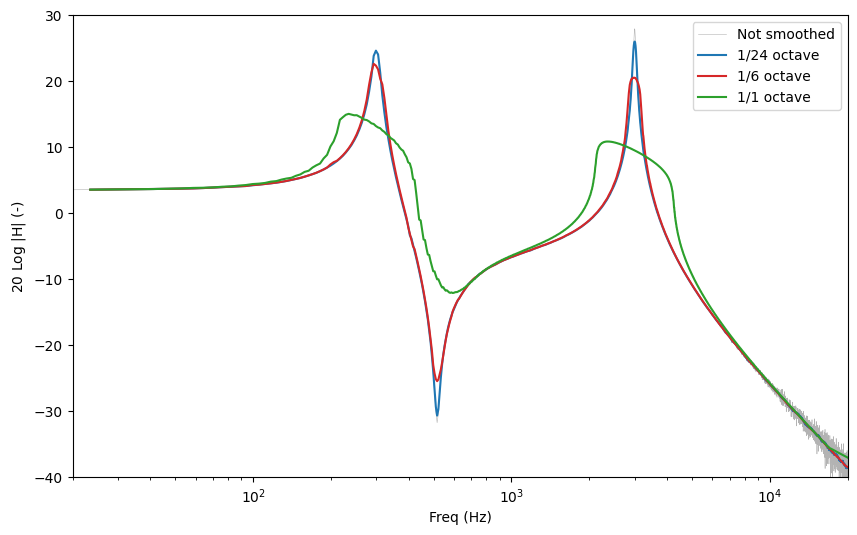

In [3]:
a = G.plot(plot_phase=False, lw=0.4, color='0.7', label='Not smoothed')
for n, color in ((24, 'tab:blue'), (6, 'tab:red'), (1, 'tab:green')):
    G.nth_oct_smooth_complex(n, freqs_range=(20, 20000)).plot(
        ax=a, plot_phase=False, color=color, label=f'1/{n} octave')
a.set_xlim(20, 20000)
a.set_ylim(-40, 30)
a.legend()

The smaller ```n```, the wider the averaging band, and the more the details
disappear. A 1/3 octave smoothing is a common choice in room acoustics, 1/12 or
1/24 octave keeps the shape of the resonances while removing most of the noise.

Note that smoothing lowers the peaks and fills the dips: it is an average, not a
peak detector. If the amplitude of a sharp resonance matters, use a large ```n```
(or no smoothing at all).

## 3. How the complex values are averaged

Averaging complex numbers can be done in several ways, and the result is not the
same. The ```mode``` argument of ```nth_oct_smooth_complex``` selects the method:

| ```mode``` | What is averaged |
| --- | --- |
| ```'amplitude_phase'``` (default) | The modulus and the unwrapped phase, separately |
| ```'complex'``` | The complex values themselves |
| ```'power'``` | The squared modulus (energetic average), and the unwrapped phase |

The difference only shows up when the phase rotates quickly inside an averaging
band. To make it visible, we add a propagation delay of 5 ms to the measured
transfer function, which is what a microphone placed 1.7 m away from a
loudspeaker would give.

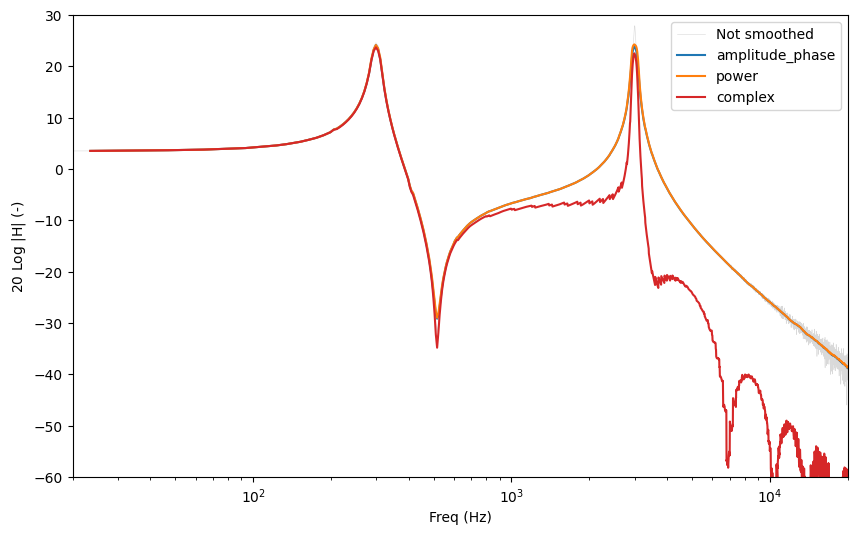

In [4]:
tau = 5e-3
Gd = G.similar(values=G.values*np.exp(-2j*np.pi*G.freqs*tau),
               desc=f'Transfer function with a {1000*tau:.0f}ms delay')

a = Gd.plot(plot_phase=False, lw=0.4, color='0.85', label='Not smoothed')
for mode, color in (('amplitude_phase', 'tab:blue'),
                    ('power', 'tab:orange'),
                    ('complex', 'tab:red')):
    Gd.nth_oct_smooth_complex(12, freqs_range=(20, 20000), mode=mode).plot(
        ax=a, plot_phase=False, color=color, label=mode)
a.set_xlim(20, 20000)
a.set_ylim(-60, 30)
a.legend()

Above a few hundred hertz, the ```'complex'``` mode collapses: inside one
1/12 octave band the phase rotates by more than a turn, and the values cancel
each other. The two other modes are unaffected, because they average the
modulus.

This is worth remembering:

- ```'complex'``` is the only linear mode (the smoothing of a sum is the sum of
  the smoothings), but it must be used on **time aligned** data only, that is,
  after the propagation delay has been removed. The next tutorial shows how
  measpy does that.
- ```'amplitude_phase'``` (the default) and ```'power'``` are insensitive to
  the delay as far as the modulus is concerned, and are the safe choice for a
  raw measurement. ```'power'``` is the relevant one for quantities that are
  already energetic, such as power spectral densities.

## 4. Smoothing a power spectral density

For a real valued spectrum, ```nth_oct_smooth``` is used. A moving average
preserves the mean level of the spectrum, which means that the total energy in a
band is unchanged: the smoothed PSD can be read as a level.

Ratio of the mean levels (should be close to 1): 0.9977


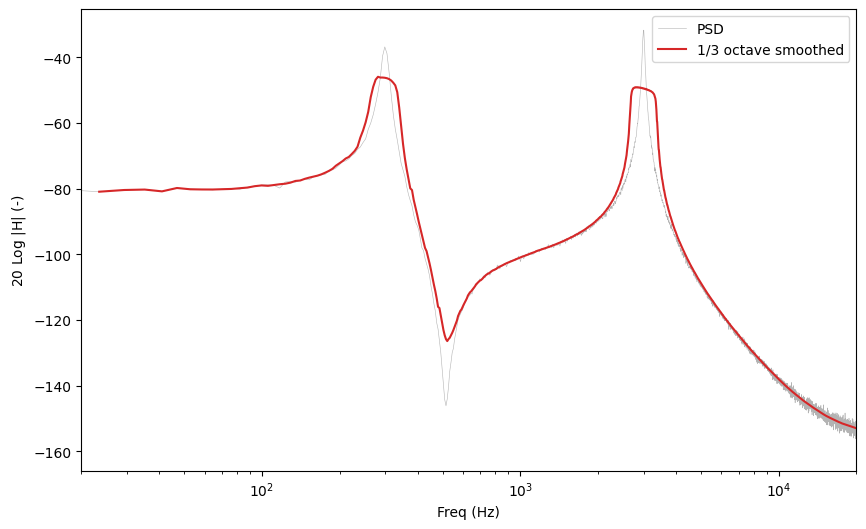

In [5]:
P = s_in.psd(nperseg=2**13)
a = P.plot(plot_phase=False, lw=0.4, color='0.7', label='PSD')
P.nth_oct_smooth(3, freqs_range=(20, 20000)).plot(
    ax=a, plot_phase=False, color='tab:red', label='1/3 octave smoothed')
a.set_xlim(20, 20000)
a.legend()

inband = (P.freqs > 100) & (P.freqs < 10000)
smoothed = P.nth_oct_smooth(3, freqs_range=(20, 20000))
print('Ratio of the mean levels (should be close to 1): '
      f'{smoothed.values[inband].mean()/P.values[inband].mean():.4f}')

## 5. Weighting objects

A ```measpy.Weighting``` object stores a gain as a function of the frequency:

- ```freqs``` : a 1D array of frequencies,
- ```amp``` : the corresponding amplitudes (linear, not dB),
- ```phase``` : the corresponding phases in radians,
- ```desc``` : a description.

Two properties give other representations of the same data: ```adb``` (the
amplitude in dB) and ```acomplex``` (the complex value ```amp*exp(1j*phase)```).

measpy provides three standard weightings as module constants: ```mp.WDBA```
(A-weighting), ```mp.WDBC``` (C-weighting) and ```mp.WDBM``` (M-weighting).

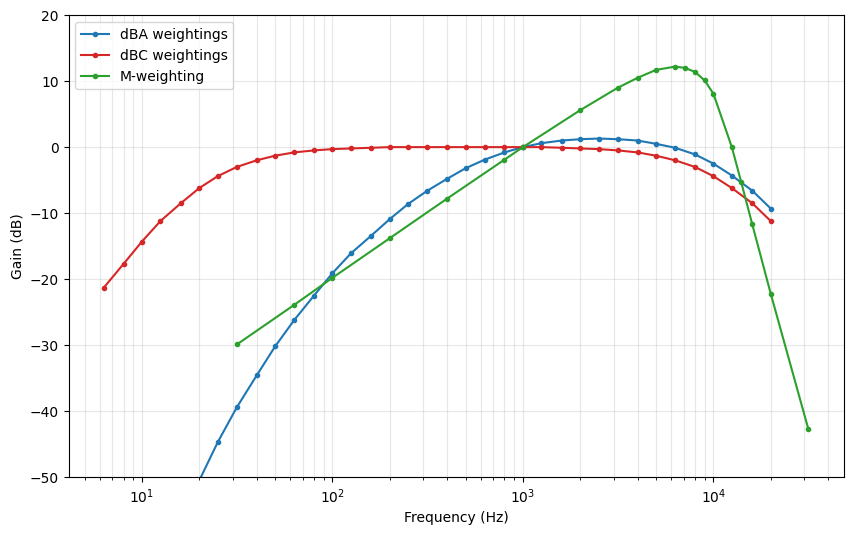

In [6]:
fig, ax = plt.subplots(1)
for w, color in ((mp.WDBA, 'tab:blue'), (mp.WDBC, 'tab:red'), (mp.WDBM, 'tab:green')):
    ax.semilogx(w.freqs, w.adb, '.-', color=color, label=w.desc)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_ylim(-50, 20)
ax.grid(which='both', alpha=0.3)
ax.legend()

### Interpolating a weighting

A weighting is defined on a few frequencies only. The
```values_at_freqs``` method interpolates it at any other frequency. The
interpolation is done on a logarithmic frequency scale, and the amplitude is
interpolated in the dB domain. Outside of the tabulated range, the value of the
closest end is used: a weighting is never extrapolated.

A-weighting at 1kHz : 0.000 dB


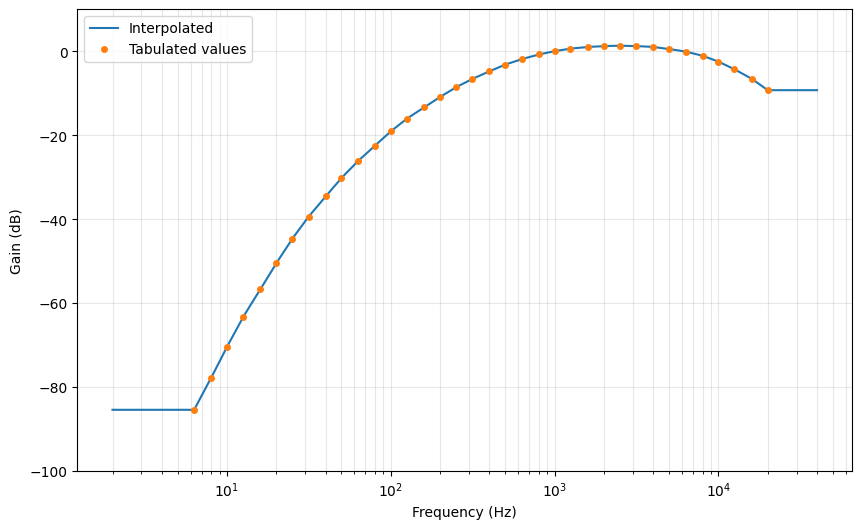

In [7]:
freqs = np.logspace(np.log10(2), np.log10(40000), 500)
values = mp.WDBA.values_at_freqs(freqs)

fig, ax = plt.subplots(1)
ax.semilogx(freqs, 20*np.log10(np.abs(values)), label='Interpolated')
ax.semilogx(mp.WDBA.freqs, mp.WDBA.adb, 'o', ms=4, label='Tabulated values')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_ylim(-100, 10)
ax.grid(which='both', alpha=0.3)
ax.legend()

print(f'A-weighting at 1kHz : {20*np.log10(abs(mp.WDBA.values_at_freqs(1000.))):.3f} dB')

### Applying a weighting to a spectrum

```apply_weighting``` multiplies a spectrum by an interpolated weighting.
With ```inverse=True```, it divides by it instead, which is how the response of
a reference sensor is removed from a measurement.

```apply_dBA``` and ```apply_dBC``` are shortcuts for the standard curves.

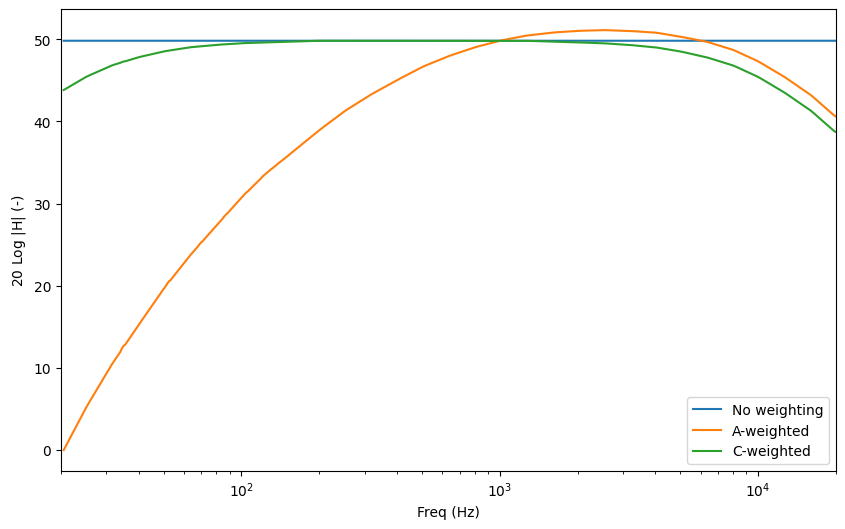

In [8]:
s_pa = mp.Signal.noise(fs=FS, dur=2.0, freqs_range=(5, FS/2), unit='Pa')
sp = s_pa.rfft()

a = sp.nth_oct_smooth_complex(12, freqs_range=(20, 20000)).plot(
    plot_phase=False, label='No weighting')
sp.apply_dBA().nth_oct_smooth_complex(12, freqs_range=(20, 20000)).plot(
    ax=a, plot_phase=False, label='A-weighted')
sp.apply_dBC().nth_oct_smooth_complex(12, freqs_range=(20, 20000)).plot(
    ax=a, plot_phase=False, label='C-weighted')
a.set_xlim(20, 20000)
a.legend()

## 6. From a spectrum to a weighting, and back

A smoothed spectrum can be reduced to a small number of points, one per 1/nth
octave band. This is what the ```nth_oct_smooth_to_weight``` (real) and
```nth_oct_smooth_to_weight_complex``` (complex) methods do: they return a
```Weighting``` object whose frequencies are the center frequencies of the
bands. Bands that contain no data (at low frequency, where the bands are
narrower than the frequency resolution) are dropped.

This is the compact form used to store a calibration curve in a file. The
```to_csv``` and ```from_csv``` methods of the ```Weighting``` class write and
read a three column file (frequency, amplitude, phase), with options to choose
between dB or linear amplitudes, and radians or degrees.

In [9]:
W = G.nth_oct_smooth_to_weight_complex(12, freqs_range=(20, 20000))
print(f'{len(W.freqs)} points instead of {G.length}')

W.to_csv('my_weighting.csv', asdB=True, asradians=True)
W2 = mp.signal.Weighting.from_csv('my_weighting.csv', asdB=True, asradians=True)
print(f'Max difference after a save/load round trip: {np.max(np.abs(W.amp-W2.amp)):.2e}')

106 points instead of 4097
Max difference after a save/load round trip: 3.55e-15


A ```Weighting``` can be turned back into a full ```Spectral``` object by
giving it to the ```similar``` method with the ```w``` keyword. The values are
interpolated at every frequency of the spectrum.

The figure below compares the moving average (computed at every frequency) with
the band center values and their interpolation. The two are close, but the
moving average keeps more detail: it is what should be used for analysis, while
the ```Weighting``` is a compact form suited to storage and to the correction of
a sensor response.

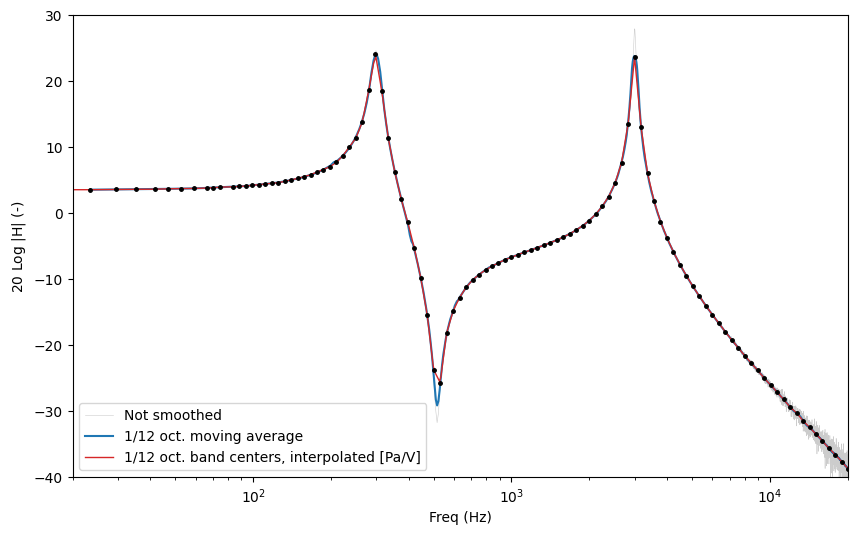

In [10]:
a = G.plot(plot_phase=False, lw=0.4, color='0.8', label='Not smoothed')
G.nth_oct_smooth_complex(12, freqs_range=(20, 20000)).plot(
    ax=a, plot_phase=False, color='tab:blue', label='1/12 oct. moving average')
G.similar(w=W, desc='1/12 oct. band centers, interpolated').plot(
    ax=a, plot_phase=False, color='tab:red', lw=1)
a.semilogx(W.freqs, W.adb, 'k.', ms=5)
a.set_xlim(20, 20000)
a.set_ylim(-40, 30)
a.legend()

## 7. A practical use: microphone response calibration

The ```measpy.utils.mic_calibration_freq``` function measures the frequency
response of a microphone by comparing it with a reference microphone, both
recording the same sound field. It returns a ```Weighting``` object.

If the response of the reference microphone is itself known (as a
```Weighting```), it is passed with the ```Wref``` argument and it is removed
from the result.

```python
import measpy as mp
from measpy.audio import audio_run_measurement

FS, DUR = 48000, 10
pa = mp.Signal(fs=FS, unit='Pa', cal=..., dbfs=...)
paref = mp.Signal(fs=FS, unit='Pa', cal=..., dbfs=...)
M = mp.Measurement(device_type='audio', fs=FS,
                   in_sig=[pa, paref], in_map=[1, 2], dur=DUR,
                   in_device='default')
audio_run_measurement(M)

# The frequency response of the microphone, as a 1/3 octave Weighting
micresp = mp.mic_calibration_freq(M.in_sig[0], M.in_sig[1], noct=3)
micresp.to_csv('my_microphone.csv')
```

The resulting curve is then applied to any later measurement made with this
microphone:

```python
w = mp.signal.Weighting.from_csv('my_microphone.csv')
corrected = measured_signal.rfft().apply_weighting(w, inverse=True).irfft()
```

## 8. Summary

| Method | Applies to | Returns |
| --- | --- | --- |
| ```nth_oct_smooth(n, ...)``` | Real spectrum | A ```Spectral```, same frequency grid |
| ```nth_oct_smooth_complex(n, ..., mode=...)``` | Complex spectrum | A ```Spectral```, same frequency grid |
| ```nth_oct_smooth_to_weight(n, ...)``` | Real spectrum | A ```Weighting```, one point per band |
| ```nth_oct_smooth_to_weight_complex(n, ...)``` | Complex spectrum | A ```Weighting```, one point per band |
| ```similar(w=W)``` | ```Spectral``` | A ```Spectral``` interpolated from a ```Weighting``` |
| ```apply_weighting(W, inverse=False)``` | ```Spectral``` | A weighted ```Spectral``` |
| ```values_at_freqs(f)``` | ```Weighting``` | Complex values at the given frequencies |

All these methods accept the standard measpy frequency range arguments
```freqs_range```, ```freq_min``` and ```freq_max```. The older ```fmin``` and
```fmax``` arguments still work but print a deprecation message.